# Class 6: Introduction to Deep Learning

## Big Idea
Neural networks learn **nonlinear transformations** of features to make better predictions.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles, make_moons, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.precision', 3)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Random seed for reproducibility
prng = np.random.RandomState(20260304)

## Interactive Exploration

**Before we code, let's build intuition!**

Open [TensorFlow Playground](https://playground.tensorflow.org/) in your browser.

## Linear vs Nonlinear Models

### Motivation: Nonlinear Decision Boundaries

Let's start with a simple problem where linear models fail: **circular decision boundary**

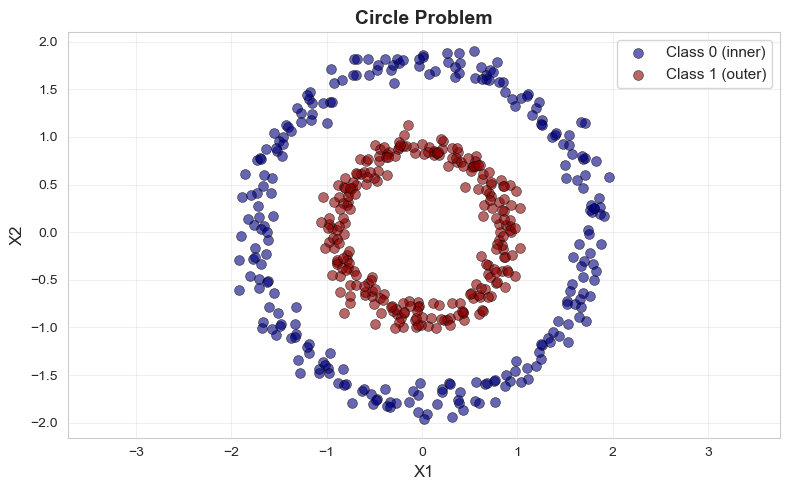

In [2]:
# Create circular data
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=prng)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

# Visualize
plt.figure()
plt.scatter(X_scaled[y_circles == 0, 0], X_scaled[y_circles == 0, 1], 
            c='navy', label='Class 0 (inner)', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.scatter(X_scaled[y_circles == 1, 0], X_scaled[y_circles == 1, 1], 
            c='darkred', label='Class 1 (outer)', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Circle Problem', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Train Neural Networks with Different Activation Functions

We'll train 3 models with 1 hidden layer containing 3 neurons:
- **Linear (identity)**: No nonlinearity
- **Sigmoid (logistic)**: Smooth nonlinear activation
- **ReLU**: Piecewise linear activation

In [3]:
# Train models with different activations
activations = ['identity', 'logistic', 'relu']
models = {}

for activation in activations:
    prng = np.random.RandomState(20260304)  # Reset for each model to ensure perfect reproducibility
    model = MLPClassifier(
        hidden_layer_sizes=(3,),
        activation=activation,
        solver='lbfgs',
        max_iter=2000,
        random_state=prng,
        alpha=0.01  # Standard regularization
    )
    model.fit(X_scaled, y_circles)
    models[activation] = model

### Visualize Decision Boundaries

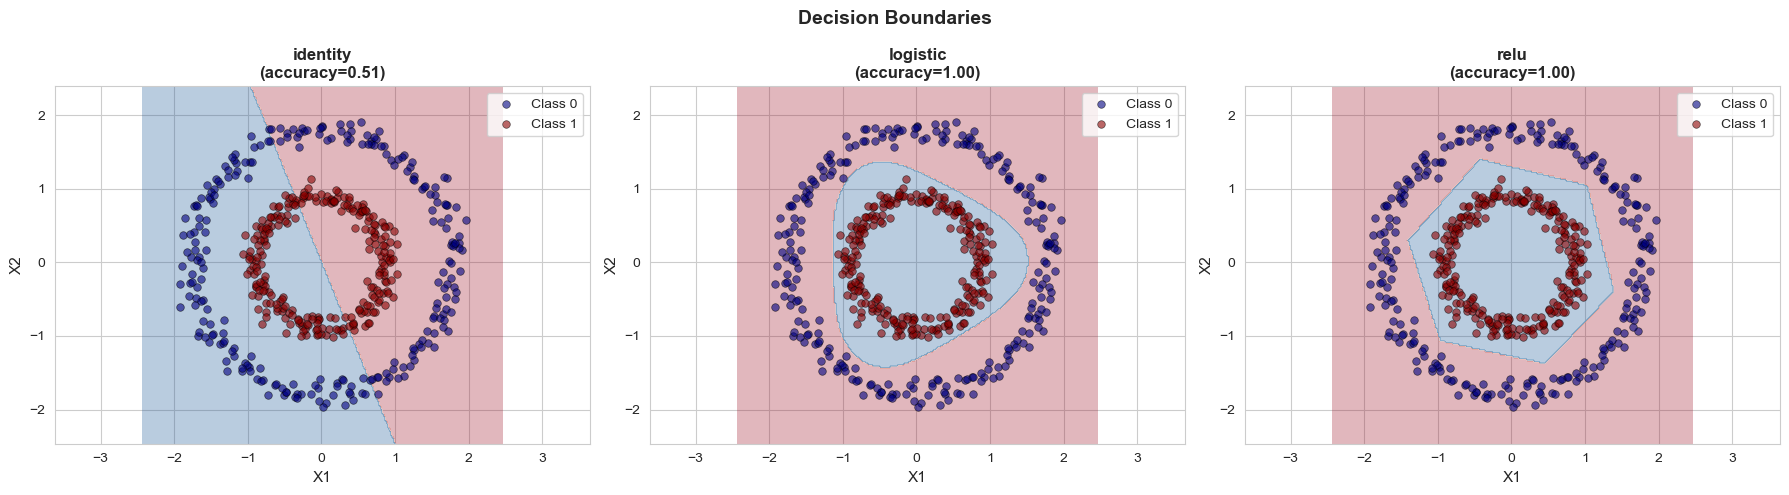

In [4]:
def plot_decision_boundary(X, y, model, title):
    """Plot decision boundary for a trained model"""
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='navy', label='Class 0', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='darkred', label='Class 1', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
    plt.xlabel('X1', fontsize=11)
    plt.ylabel('X2', fontsize=11)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.axis('equal')

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (activation, model) in enumerate(models.items()):
    plt.sca(axes[idx])
    score = model.score(X_scaled, y_circles)
    plot_decision_boundary(X_scaled, y_circles, model, 
                          f'{activation}\n(accuracy={score:.2f})')
plt.suptitle('Decision Boundaries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Deep Dive: How Hidden Neurons Transform the Data

Let's slice through the data at X2=0 and visualize what happens inside the hidden layer.

In [5]:
def visualize_hidden_layer_slice(model, activation_name, x1_range=(-2, 2), x2_fixed=0.0):
    """
    Visualize what happens in hidden layer along a 1D slice (x2=fixed)
    """
    # Create a slice of data points
    x1_vals = np.linspace(x1_range[0], x1_range[1], 200)
    x2_vals = np.full_like(x1_vals, x2_fixed)
    X_slice = np.column_stack([x1_vals, x2_vals])
    
    # Get weights and biases
    W1 = model.coefs_[0]  # Input to hidden: (2, 3)
    b1 = model.intercepts_[0]  # Hidden biases: (3,)
    W2 = model.coefs_[1]  # Hidden to output: (3, 1)
    b2 = model.intercepts_[1]  # Output biases: (1,)
    
    # Compute hidden layer pre-activation (z = X @ W1 + b1)
    z_hidden = X_slice @ W1 + b1  # (200, 3)
    
    # Apply activation function
    if activation_name == 'identity':
        h_hidden = z_hidden
        activation_fn = lambda x: x
    elif activation_name == 'logistic':
        h_hidden = 1 / (1 + np.exp(-z_hidden))
        activation_fn = lambda x: 1 / (1 + np.exp(-x))
    elif activation_name == 'relu':
        h_hidden = np.maximum(0, z_hidden)
        activation_fn = lambda x: np.maximum(0, x)
    
    # Compute output (before sigmoid)
    output_logit = h_hidden @ W2.flatten() + b2[0]
    output_prob = 1 / (1 + np.exp(-output_logit))
    
    return {
        'x1_vals': x1_vals,
        'z_hidden': z_hidden,
        'h_hidden': h_hidden,
        'output_logit': output_logit,
        'output_prob': output_prob,
        'activation_fn': activation_fn,
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }


def plot_slice_location(X_scaled, y_circles, x2_fixed=0.0):
    """Plot where we're slicing the data"""
    fig, ax = plt.subplots(1, 1)
    ax.scatter(X_scaled[y_circles == 0, 0], X_scaled[y_circles == 0, 1], 
                c='navy', alpha=0.5, s=50, label='Class 0 (inner)', edgecolors='k', linewidth=0.5)
    ax.scatter(X_scaled[y_circles == 1, 0], X_scaled[y_circles == 1, 1], 
                c='darkred', alpha=0.5, s=50, label='Class 1 (outer)', edgecolors='k', linewidth=0.5)
    ax.axhline(y=x2_fixed, color='black', linestyle='--', linewidth=3, label=f'Slice at X2={x2_fixed}')
    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    ax.set_title(f'Circle Problem: 1D Slice at X2={x2_fixed}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_activation_comparison(models_data, activation_names, x2_fixed=0.0):
    """
    Create a comprehensive comparison chart with:
    - 3 rows (one per activation function)
    - 4 columns: activation function, pre-activation, post-activation+output, final prediction
    """
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    
    colors = ['C0', 'C1', 'C2']  # Colors for the 3 neurons
    
    for row_idx, (activation_name, data) in enumerate(zip(activation_names, models_data)):
        x1_vals = data['x1_vals']
        z_hidden = data['z_hidden']
        h_hidden = data['h_hidden']
        output_logit = data['output_logit']
        output_prob = data['output_prob']
        activation_fn = data['activation_fn']
        
        # Column 1: Activation function shape
        ax = axes[row_idx, 0]
        z_range = np.linspace(-5, 5, 100)
        ax.plot(z_range, activation_fn(z_range), 'purple', linewidth=3)
        ax.set_xlabel('Input (z)', fontsize=11)
        ax.set_ylabel('Output h(z)', fontsize=11)
        ax.set_title(f'{activation_name.capitalize()}\nActivation Function', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.axvline(0, color='k', linewidth=0.5)
        
        # Column 2: Pre-activation values (z) for all 3 neurons
        ax = axes[row_idx, 1]
        for i in range(3):
            ax.plot(x1_vals, z_hidden[:, i], color=colors[i], linewidth=2, label=f'Neuron {i+1}')
        ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Pre-activation (z)', fontsize=11)
        ax.set_title('Hidden Layer\nPre-Activation (z = w·x + b)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Column 3: Post-activation values (h) + output logit
        ax = axes[row_idx, 2]
        for i in range(3):
            ax.plot(x1_vals, h_hidden[:, i], color=colors[i], linewidth=2, 
                   label=f'h{i+1}', alpha=0.7, linestyle='--')
        ax.plot(x1_vals, output_logit, 'purple', linewidth=3, label='Output (logit)')
        ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)
        ax.set_title(f'After {activation_name.capitalize()}\n+ Output (before sigmoid)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3)
        
        # Column 4: Final prediction (after sigmoid)
        ax = axes[row_idx, 3]
        ax.plot(x1_vals, output_prob, 'purple', linewidth=3, label='P(Class 1)')
        ax.axhline(0.5, color='k', linestyle='--', linewidth=1.5, alpha=0.7, label='Decision boundary')
        ax.fill_between(x1_vals, 0, output_prob, where=(output_prob < 0.5), 
                          alpha=0.3, color='blue', label='Predict Class 0')
        ax.fill_between(x1_vals, output_prob, 1, where=(output_prob >= 0.5), 
                          alpha=0.3, color='red', label='Predict Class 1')
        ax.set_xlabel('X1 (at X2=0)', fontsize=11)
        ax.set_ylabel('Probability', fontsize=11)
        ax.set_title('Final Prediction\n(after sigmoid)', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Activation Function Comparison: Hidden Layer Visualization (X2={x2_fixed})', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

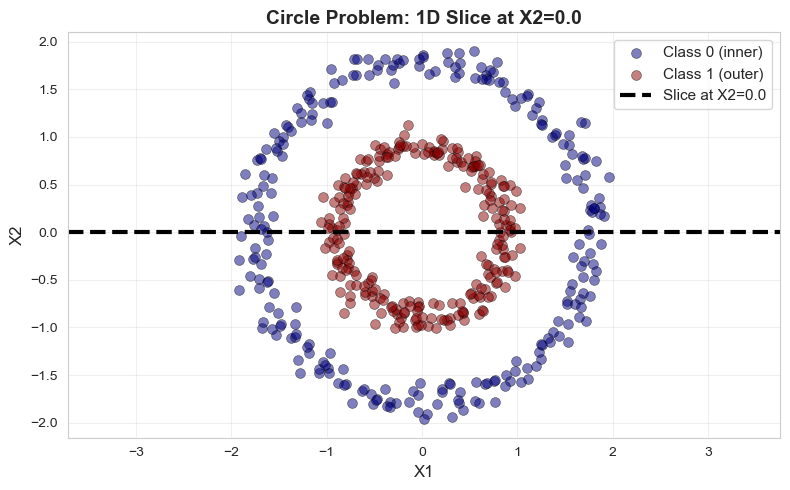

In [6]:
# Show where we're slicing the data
plot_slice_location(X_scaled, y_circles, x2_fixed=0.0)

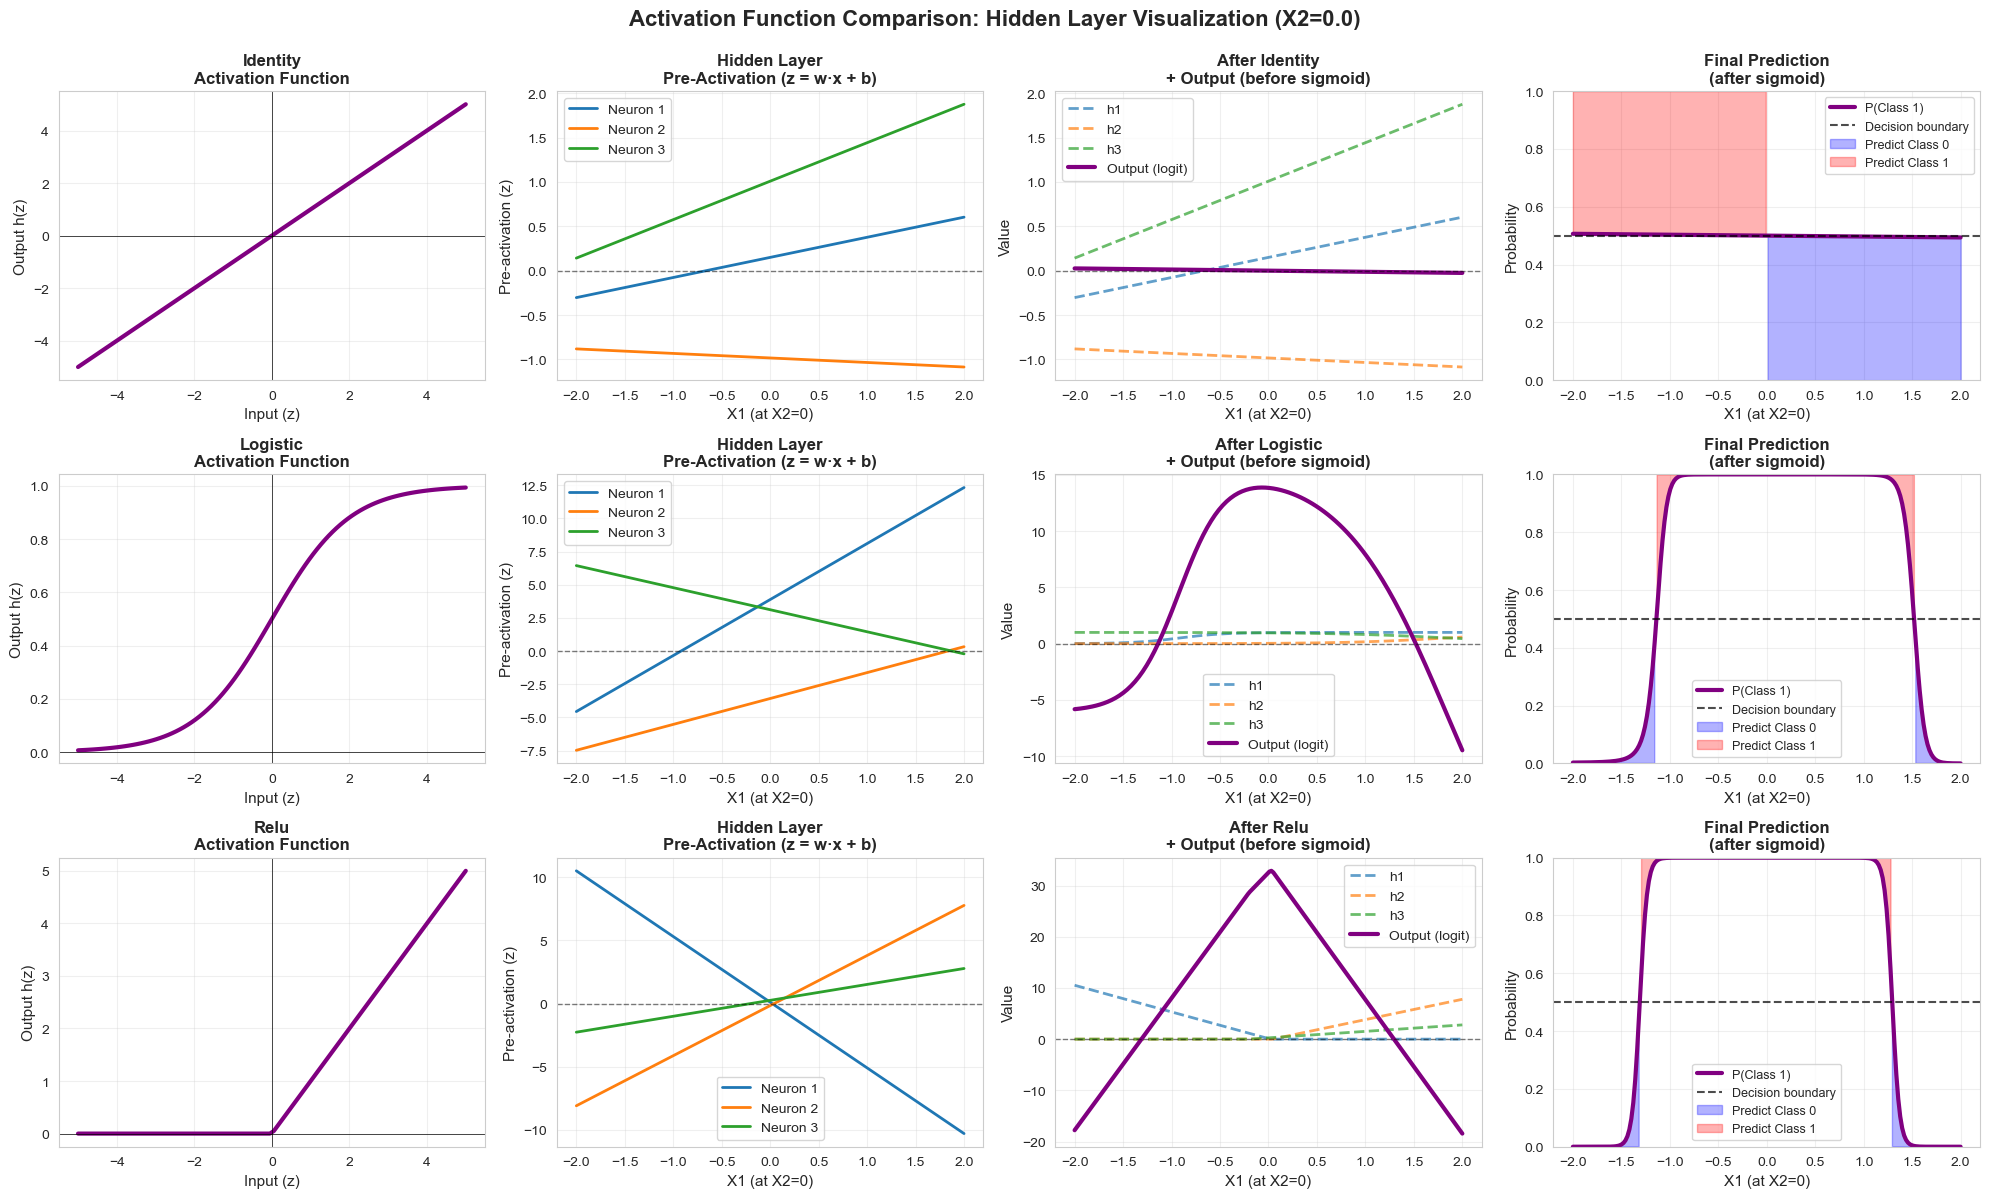

In [7]:
# Compute slice data for all activation functions
activation_names = ['identity', 'logistic', 'relu']
models_data = []

for activation_name in activation_names:
    if activation_name in models:
        data = visualize_hidden_layer_slice(models[activation_name], activation_name, x2_fixed=0.0)
        models_data.append(data)

# Plot comprehensive comparison
plot_activation_comparison(models_data, activation_names, x2_fixed=0.0)